# AQI Model Training and Comparison

Trains and compares models for 24, 48, and 72 hour AQI forecasting on Karachi,
Lahore, and Islamabad. Split is chronological (oldest data trains, newest tests)
so the numbers are honest. Compares naive baselines against ridge, random forest,
and XGBoost, scored per city and per horizon against the benchmark
(R2 >= 0.7, RMSE 20-30, MAE 10-20).

In [8]:
# 1. Load data and setup

import sys
sys.path.append("..")

import numpy as np
import pandas as pd

from src.feature_store import read_all
from src.feature_engineering import get_feature_columns, TARGETS
from src.config import FORECAST_HORIZONS
from src.evaluation import score_all, check_targets, results_table

pd.set_option("display.max_columns", 100)

df = read_all()
print("rows:", len(df))
print("cities:", df["city_id"].unique())
print("date range:", df.index.min(), "->", df.index.max())

rows: 86880
cities: ['pk-islamabad' 'pk-lahore' 'pk-karachi' 'pk-quetta' 'pk-peshawar']
date range: 2024-07-26 00:00:00+00:00 -> 2026-07-26 23:00:00+00:00


## 1.1. Chronological split

Split by time, not randomly. Train on the oldest 70 percent, validate on the
next 15, test on the newest 15. Same date boundaries for every city so no city's
future leaks into another's past.

In [9]:
# drop rows without all targets present (recent rows have no future yet)
data = df.dropna(subset=TARGETS + get_feature_columns(df)).sort_index()

# global date cutoffs so every city uses the same split points
times = data.index.unique().sort_values()
train_end = times[int(len(times) * 0.70)]
val_end = times[int(len(times) * 0.85)]

train = data[data.index <= train_end]
val = data[(data.index > train_end) & (data.index <= val_end)]
test = data[data.index > val_end]

print("train:", len(train), "->", train.index.min().date(), train.index.max().date())
print("val:  ", len(val), "->", val.index.min().date(), val.index.max().date())
print("test: ", len(test), "->", test.index.min().date(), test.index.max().date())

train: 60819 -> 2024-07-26 2025-12-17
val:   13105 -> 2025-12-17 2026-04-05
test:  12596 -> 2026-04-05 2026-07-23


## 3. Baselines

Persistence predicts future AQI equals current AQI. Seasonal naive predicts it
equals AQI the same hour last week. Every real model must beat these.

In [10]:
# collect all results here as we go
all_results = []

def add_result(city, horizon, model, metrics):
    row = {"city": city, "horizon": horizon, "model": model}
    row.update(metrics)
    all_results.append(row)

# score baselines per city per horizon on the test set
for city_id, g in test.groupby("city_id"):
    for h in FORECAST_HORIZONS:
        y_true = g[f"aqi_t_plus_{h}"]
        persistence = g["aqi"]
        seasonal = g["aqi_lag_168"]
        add_result(city_id, h, "persistence", score_all(y_true, persistence))
        add_result(city_id, h, "seasonal_naive", score_all(y_true, seasonal))

results_table(all_results)

,city,horizon,model,rmse,mae,r2
0,pk-islamabad,24,persistence,16.472158,11.913540,0.762291
1,pk-islamabad,24,seasonal_naive,35.552778,26.668026,-0.107366
2,pk-islamabad,48,persistence,22.912994,16.754078,0.539751
3,pk-islamabad,48,seasonal_naive,35.215041,26.171697,-0.087140
4,pk-islamabad,72,persistence,27.480425,20.558728,0.329486
5,pk-islamabad,72,seasonal_naive,35.519783,26.550571,-0.120215
6,pk-karachi,24,persistence,12.177604,8.429445,0.291015
7,pk-karachi,24,seasonal_naive,22.835383,17.411501,-1.493045
8,pk-karachi,48,persistence,16.252042,11.753670,-0.253409
9,pk-karachi,48,seasonal_naive,22.491234,17.051387,-1.400510


## 4. Feature setup for the models

The models use the numeric feature columns. city_id is turned into numbers so the
pooled model can tell cities apart. Same columns across all horizons.

In [11]:
feature_cols = get_feature_columns(data)

# encode city_id as an integer code so tree models can use it
city_codes = {c: i for i, c in enumerate(data["city_id"].unique())}
for part in (train, val, test):
    part["city_code"] = part["city_id"].map(city_codes)

model_features = feature_cols + ["city_code"]

X_train = train[model_features]
X_val = val[model_features]
X_test = test[model_features]

print("number of features:", len(model_features))

number of features: 68


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


## 5. Train ridge, random forest, and XGBoost

One model per horizon (direct multi-horizon). Ridge needs scaling, the tree
models do not. Scale is fit on train only.

In [12]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# fit one scaler on train for ridge
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# store trained models so we can inspect the best one later
trained = {}

for h in FORECAST_HORIZONS:
    y_train = train[f"aqi_t_plus_{h}"]

    # ridge (scaled)
    ridge = Ridge(alpha=1.0).fit(X_train_s, y_train)

    # random forest
    rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
    rf.fit(X_train, y_train)

    # xgboost
    xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                       subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                       random_state=42)
    xgb.fit(X_train, y_train)

    trained[h] = {"ridge": ridge, "rf": rf, "xgb": xgb}
    print(f"trained models for horizon {h}h")

trained models for horizon 24h
trained models for horizon 48h
trained models for horizon 72h


## 6. Score the models per city per horizon

Predict on the test set, then break the metrics down by city so we can compare
against the benchmark for each city.

In [13]:
for h in FORECAST_HORIZONS:
    preds = {
        "ridge": trained[h]["ridge"].predict(X_test_s),
        "rf": trained[h]["rf"].predict(X_test),
        "xgb": trained[h]["xgb"].predict(X_test),
    }
    # attach predictions to the test frame so we can group by city
    tmp = test.copy()
    for name, p in preds.items():
        tmp[f"pred_{name}"] = p

    for city_id, g in tmp.groupby("city_id"):
        y_true = g[f"aqi_t_plus_{h}"]
        baseline = g["aqi"]  # persistence, for the skill score
        for name in preds:
            m = score_all(y_true, g[f"pred_{name}"], y_baseline=baseline)
            add_result(city_id, h, name, m)

table = results_table(all_results)
table

,city,horizon,model,rmse,mae,r2,skill
0,pk-islamabad,24,persistence,16.472158,11.913540,0.762291,NaN
1,pk-islamabad,24,rf,15.919421,12.104139,0.777977,0.065986
2,pk-islamabad,24,ridge,16.036919,12.422736,0.774687,0.052147
3,pk-islamabad,24,seasonal_naive,35.552778,26.668026,-0.107366,NaN
4,pk-islamabad,24,xgb,15.786251,11.922854,0.781676,0.081547
...,...,...,...,...,...,...,...
70,pk-quetta,72,persistence,52.604759,40.290458,-1.055786,NaN
71,pk-quetta,72,rf,41.166846,31.220832,-0.258992,0.387586
72,pk-quetta,72,ridge,40.002489,29.440285,-0.188781,0.421739
73,pk-quetta,72,seasonal_naive,52.216647,39.690458,-1.025564,NaN


## 7. Check against the benchmark

Flag which model, city, horizon combinations clear R2 >= 0.7, RMSE <= 30,
MAE <= 20.

In [14]:
# add pass/fail columns to the results table
checks = table.apply(
    lambda r: pd.Series(check_targets(r.to_dict())), axis=1
)
full = pd.concat([table, checks], axis=1)

# show only the real models (not baselines) and whether they pass
models_only = full[full["model"].isin(["ridge", "rf", "xgb"])]
models_only[["city", "horizon", "model", "rmse", "mae", "r2", "skill", "all_ok"]]

,city,horizon,model,rmse,mae,r2,skill,all_ok
1,pk-islamabad,24,rf,15.919421,12.104139,0.777977,0.065986,True
2,pk-islamabad,24,ridge,16.036919,12.422736,0.774687,0.052147,True
4,pk-islamabad,24,xgb,15.786251,11.922854,0.781676,0.081547,True
6,pk-islamabad,48,rf,22.058032,17.524378,0.573457,0.073235,False
7,pk-islamabad,48,ridge,21.969443,17.574407,0.576877,0.080664,False
9,pk-islamabad,48,xgb,21.665058,16.930726,0.588520,0.105962,False
11,pk-islamabad,72,rf,27.043556,21.667086,0.350636,0.031542,False
12,pk-islamabad,72,ridge,25.174239,20.452402,0.437305,0.160799,False
14,pk-islamabad,72,xgb,25.453338,20.298551,0.424759,0.142088,False
16,pk-karachi,24,rf,11.164890,7.930204,0.404033,0.159408,False


In [15]:
# quick summary: best model per city per horizon by RMSE
best = (models_only.sort_values("rmse")
        .groupby(["city", "horizon"])
        .first()
        .reset_index()[["city", "horizon", "model", "rmse", "mae", "r2", "all_ok"]])
best

,city,horizon,model,rmse,mae,r2,all_ok
0,pk-islamabad,24,xgb,15.786251,11.922854,0.781676,True
1,pk-islamabad,48,xgb,21.665058,16.930726,0.588520,False
2,pk-islamabad,72,ridge,25.174239,20.452402,0.437305,False
3,pk-karachi,24,xgb,10.424255,7.389065,0.480478,False
4,pk-karachi,48,xgb,14.174018,10.481487,0.046627,False
5,pk-karachi,72,xgb,15.368492,11.516950,-0.182684,False
6,pk-lahore,24,ridge,27.105217,18.349949,0.595759,False
7,pk-lahore,48,ridge,33.672060,23.314035,0.372507,False
8,pk-lahore,72,ridge,34.571870,24.333834,0.337085,False
9,pk-peshawar,24,xgb,18.116614,13.819503,0.667561,False


## 8. Tune XGBoost per horizon

Search over hyperparameters using the validation set to pick the best config for
each horizon, with early stopping so trees stop when validation stops improving.
This is the main push to lift R2, especially at 48h and 72h.

In [16]:
from itertools import product

# a focused grid, not huge, tuned for time series with many features
param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "min_child_weight": [1, 5],
}

# build all combinations
combos = list(product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
    param_grid["min_child_weight"],
))
print("configs to try per horizon:", len(combos))

configs to try per horizon: 72


In [17]:
from src.evaluation import rmse as rmse_fn

# tune one XGBoost per horizon, pick best by validation RMSE
tuned = {}

for h in FORECAST_HORIZONS:
    y_train = train[f"aqi_t_plus_{h}"]
    y_val = val[f"aqi_t_plus_{h}"]

    best_rmse = float("inf")
    best_model = None
    best_params = None

    for (md, lr, ss, cs, mcw) in combos:
        model = XGBRegressor(
            n_estimators=2000,          # high, early stopping cuts it down
            max_depth=md,
            learning_rate=lr,
            subsample=ss,
            colsample_bytree=cs,
            min_child_weight=mcw,
            n_jobs=-1,
            random_state=42,
            early_stopping_rounds=50,
            eval_metric="rmse",
        )
        model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  verbose=False)
        val_pred = model.predict(X_val)
        r = rmse_fn(y_val, val_pred)
        if r < best_rmse:
            best_rmse = r
            best_model = model
            best_params = (md, lr, ss, cs, mcw)

    tuned[h] = best_model
    print(f"horizon {h}h: best val RMSE {best_rmse:.2f}, "
          f"params depth={best_params[0]} lr={best_params[1]} "
          f"sub={best_params[2]} col={best_params[3]} mcw={best_params[4]}, "
          f"trees={best_model.best_iteration}")

horizon 24h: best val RMSE 18.76, params depth=4 lr=0.03 sub=0.7 col=0.7 mcw=5, trees=722
horizon 48h: best val RMSE 23.82, params depth=4 lr=0.05 sub=0.9 col=0.9 mcw=1, trees=151
horizon 72h: best val RMSE 24.82, params depth=4 lr=0.05 sub=0.7 col=0.9 mcw=5, trees=279


## 9. Score the tuned model on the test set

Same per city per horizon breakdown, against the benchmark.

In [18]:
tuned_results = []

def add_tuned(city, horizon, metrics):
    row = {"city": city, "horizon": horizon, "model": "xgb_tuned"}
    row.update(metrics)
    tuned_results.append(row)

for h in FORECAST_HORIZONS:
    tmp = test.copy()
    tmp["pred"] = tuned[h].predict(X_test)
    for city_id, g in tmp.groupby("city_id"):
        y_true = g[f"aqi_t_plus_{h}"]
        baseline = g["aqi"]
        add_tuned(city_id, h, score_all(y_true, g["pred"], y_baseline=baseline))

tuned_table = results_table(tuned_results)

# add pass/fail against the benchmark
checks = tuned_table.apply(lambda r: pd.Series(check_targets(r.to_dict())), axis=1)
tuned_full = pd.concat([tuned_table, checks], axis=1)
tuned_full[["city", "horizon", "rmse", "mae", "r2", "skill", "all_ok"]]

,city,horizon,rmse,mae,r2,skill,all_ok
0,pk-islamabad,24,15.485357,11.705197,0.789919,0.116225,True
1,pk-islamabad,48,21.693781,17.081201,0.587428,0.103590,False
2,pk-islamabad,72,24.633563,20.121258,0.461215,0.196460,False
3,pk-karachi,24,10.310793,7.221038,0.491726,0.283097,False
4,pk-karachi,48,14.345158,10.952980,0.023465,0.220897,False
5,pk-karachi,72,15.627638,11.918950,-0.222905,0.237465,False
6,pk-lahore,24,26.520354,17.833004,0.613015,0.443565,False
7,pk-lahore,48,34.286380,24.355777,0.349402,0.298212,False
8,pk-lahore,72,37.635099,27.794654,0.214405,0.162255,False
9,pk-peshawar,24,17.864310,13.555518,0.676756,0.234300,False


In [19]:
# compare tuned vs untuned xgb, R2 side by side
untuned_xgb = table[table["model"] == "xgb"][["city", "horizon", "r2"]]
untuned_xgb = untuned_xgb.rename(columns={"r2": "r2_untuned"})
tuned_r2 = tuned_table[["city", "horizon", "r2"]].rename(columns={"r2": "r2_tuned"})

compare = untuned_xgb.merge(tuned_r2, on=["city", "horizon"])
compare["improvement"] = compare["r2_tuned"] - compare["r2_untuned"]
compare

,city,horizon,r2_untuned,r2_tuned,improvement
0,pk-islamabad,24,0.781676,0.789919,0.008243
1,pk-islamabad,48,0.588520,0.587428,-0.001092
2,pk-islamabad,72,0.424759,0.461215,0.036457
3,pk-karachi,24,0.480478,0.491726,0.011248
4,pk-karachi,48,0.046627,0.023465,-0.023161
5,pk-karachi,72,-0.182684,-0.222905,-0.040221
6,pk-lahore,24,0.570460,0.613015,0.042555
7,pk-lahore,48,0.227147,0.349402,0.122256
8,pk-lahore,72,0.117055,0.214405,0.097350
9,pk-peshawar,24,0.667561,0.676756,0.009195


## 10. Per city models

Train a separate tuned XGBoost for each city, using only that city's data. Tests
whether dedicated models beat the pooled model, especially for Lahore's high
variance. Compared against the pooled tuned model on the same test set.

In [20]:
# reuse the same tuning grid, but train per city
def tune_xgb(X_tr, y_tr, X_v, y_v):
    best_rmse = float("inf")
    best_model = None
    for (md, lr, ss, cs, mcw) in combos:
        m = XGBRegressor(
            n_estimators=2000, max_depth=md, learning_rate=lr,
            subsample=ss, colsample_bytree=cs, min_child_weight=mcw,
            n_jobs=-1, random_state=42,
            early_stopping_rounds=50, eval_metric="rmse",
        )
        m.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        r = rmse_fn(y_v, m.predict(X_v))
        if r < best_rmse:
            best_rmse, best_model = r, m
    return best_model

In [21]:
# train per city per horizon (this takes a while, same grid but 3x cities)
percity_models = {}   # {(city_id, h): model}

for city_id in data["city_id"].unique():
    tr = train[train["city_id"] == city_id]
    vl = val[val["city_id"] == city_id]
    Xtr = tr[model_features]
    Xvl = vl[model_features]
    for h in FORECAST_HORIZONS:
        model = tune_xgb(Xtr, tr[f"aqi_t_plus_{h}"], Xvl, vl[f"aqi_t_plus_{h}"])
        percity_models[(city_id, h)] = model
    print(f"done {city_id}")

done pk-islamabad
done pk-lahore
done pk-karachi
done pk-quetta
done pk-peshawar


In [22]:
# score per city models on the test set
percity_results = []

for city_id in data["city_id"].unique():
    te = test[test["city_id"] == city_id]
    Xte = te[model_features]
    for h in FORECAST_HORIZONS:
        y_true = te[f"aqi_t_plus_{h}"]
        pred = percity_models[(city_id, h)].predict(Xte)
        m = score_all(y_true, pred, y_baseline=te["aqi"])
        row = {"city": city_id, "horizon": h, "model": "xgb_percity"}
        row.update(m)
        percity_results.append(row)

percity_table = results_table(percity_results)
checks = percity_table.apply(lambda r: pd.Series(check_targets(r.to_dict())), axis=1)
percity_full = pd.concat([percity_table, checks], axis=1)
percity_full[["city", "horizon", "rmse", "mae", "r2", "skill", "all_ok"]]

,city,horizon,rmse,mae,r2,skill,all_ok
0,pk-islamabad,24,15.657119,11.898734,0.785233,0.096511,True
1,pk-islamabad,48,21.776465,16.975647,0.584277,0.096744,False
2,pk-islamabad,72,24.759043,19.516801,0.455712,0.188253,False
3,pk-karachi,24,10.340887,7.068660,0.488755,0.278906,False
4,pk-karachi,48,13.568729,9.840869,0.126314,0.302952,False
5,pk-karachi,72,13.978133,10.226842,0.021627,0.389941,False
6,pk-lahore,24,27.354365,19.216426,0.588293,0.408017,False
7,pk-lahore,48,36.574779,26.498023,0.259657,0.201406,False
8,pk-lahore,72,38.267567,28.596648,0.187779,0.133862,False
9,pk-peshawar,24,18.997841,14.733686,0.634433,0.134046,False


In [23]:
# pooled tuned vs per city, R2 and RMSE side by side
pool = tuned_table[["city", "horizon", "r2", "rmse"]].rename(
    columns={"r2": "r2_pooled", "rmse": "rmse_pooled"})
pc = percity_table[["city", "horizon", "r2", "rmse"]].rename(
    columns={"r2": "r2_percity", "rmse": "rmse_percity"})

vs = pool.merge(pc, on=["city", "horizon"])
vs["r2_gain"] = vs["r2_percity"] - vs["r2_pooled"]
vs["rmse_gain"] = vs["rmse_pooled"] - vs["rmse_percity"]  # positive = per city better
vs

,city,horizon,r2_pooled,rmse_pooled,r2_percity,rmse_percity,r2_gain,rmse_gain
0,pk-islamabad,24,0.789919,15.485357,0.785233,15.657119,-0.004686,-0.171762
1,pk-islamabad,48,0.587428,21.693781,0.584277,21.776465,-0.003151,-0.082685
2,pk-islamabad,72,0.461215,24.633563,0.455712,24.759043,-0.005503,-0.125481
3,pk-karachi,24,0.491726,10.310793,0.488755,10.340887,-0.002971,-0.030093
4,pk-karachi,48,0.023465,14.345158,0.126314,13.568729,0.102849,0.776429
5,pk-karachi,72,-0.222905,15.627638,0.021627,13.978133,0.244532,1.649506
6,pk-lahore,24,0.613015,26.520354,0.588293,27.354365,-0.024722,-0.834010
7,pk-lahore,48,0.349402,34.286380,0.259657,36.574779,-0.089745,-2.288399
8,pk-lahore,72,0.214405,37.635099,0.187779,38.267567,-0.026626,-0.632468
9,pk-peshawar,24,0.676756,17.864310,0.634433,18.997841,-0.042323,-1.133531


## 11. Full model comparison on 3 core cities

Compares every model family on Karachi, Lahore, and Islamabad, scored the same
way, in one table: baselines, ridge, random forest, XGBoost, tuned XGBoost,
SARIMAX (statistical), and a small LSTM (deep learning). Runs on 3 cities for
speed. The final production model still uses all 5 cities.

In [24]:
# restrict to the 3 core cities and rebuild splits for a clean comparison
core_cities = ["pk-karachi", "pk-lahore", "pk-islamabad"]
cdata = data[data["city_id"].isin(core_cities)].sort_index()

ctimes = cdata.index.unique().sort_values()
c_train_end = ctimes[int(len(ctimes) * 0.70)]
c_val_end = ctimes[int(len(ctimes) * 0.85)]

ctrain = cdata[cdata.index <= c_train_end].copy()
cval = cdata[(cdata.index > c_train_end) & (cdata.index <= c_val_end)].copy()
ctest = cdata[cdata.index > c_val_end].copy()

# city code for the 3 cities
ccodes = {c: i for i, c in enumerate(core_cities)}
for part in (ctrain, cval, ctest):
    part["city_code"] = part["city_id"].map(ccodes)

cfeatures = feature_cols + ["city_code"]
Xc_train, Xc_val, Xc_test = ctrain[cfeatures], cval[cfeatures], ctest[cfeatures]

# scaler for models that need it
cscaler = StandardScaler().fit(Xc_train)
Xc_train_s = cscaler.transform(Xc_train)
Xc_val_s = cscaler.transform(Xc_val)
Xc_test_s = cscaler.transform(Xc_test)

print("core train/val/test:", len(ctrain), len(cval), len(ctest))

# one shared results list for the whole comparison
comp = []
def add_comp(model, city, h, metrics):
    row = {"model": model, "city": city, "horizon": h}
    row.update(metrics)
    comp.append(row)

core train/val/test: 36339 7788 7785


In [25]:
# baselines: persistence and seasonal naive
for city_id, g in ctest.groupby("city_id"):
    for h in FORECAST_HORIZONS:
        y_true = g[f"aqi_t_plus_{h}"]
        add_comp("persistence", city_id, h, score_all(y_true, g["aqi"]))
        add_comp("seasonal_naive", city_id, h, score_all(y_true, g["aqi_lag_168"]))
print("baselines done")

baselines done


In [26]:
# ridge, random forest, xgboost, tuned xgboost
for h in FORECAST_HORIZONS:
    y_tr = ctrain[f"aqi_t_plus_{h}"]

    ridge = Ridge(alpha=1.0).fit(Xc_train_s, y_tr)
    rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42).fit(Xc_train, y_tr)
    xgb = XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=6,
                       subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
                       random_state=42).fit(Xc_train, y_tr)
    xgb_t = tune_xgb(Xc_train, y_tr, Xc_val, cval[f"aqi_t_plus_{h}"])

    tmp = ctest.copy()
    tmp["p_ridge"] = ridge.predict(Xc_test_s)
    tmp["p_rf"] = rf.predict(Xc_test)
    tmp["p_xgb"] = xgb.predict(Xc_test)
    tmp["p_xgbt"] = xgb_t.predict(Xc_test)

    for city_id, g in tmp.groupby("city_id"):
        y_true = g[f"aqi_t_plus_{h}"]
        base = g["aqi"]
        add_comp("ridge", city_id, h, score_all(y_true, g["p_ridge"], base))
        add_comp("random_forest", city_id, h, score_all(y_true, g["p_rf"], base))
        add_comp("xgboost", city_id, h, score_all(y_true, g["p_xgb"], base))
        add_comp("xgboost_tuned", city_id, h, score_all(y_true, g["p_xgbt"], base))
    print(f"sklearn/xgb done for {h}h")

sklearn/xgb done for 24h
sklearn/xgb done for 48h
sklearn/xgb done for 72h


### SARIMAX (statistical model)

Fit per city on the AQI series with weather as exogenous inputs. Predicts the
value h steps ahead. This is the statistical model the brief asks for. It is slow
to fit, so give it a few minutes.

In [27]:
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")  # SARIMAX is noisy about convergence

# small set of exogenous weather features to keep it tractable
exog_cols = ["wind_speed_10m", "temperature_2m", "surface_pressure", "stagnation_index"]

for city_id in core_cities:
    tr = ctrain[ctrain["city_id"] == city_id].sort_index()
    te = ctest[ctest["city_id"] == city_id].sort_index()

    y_tr = tr["aqi"].astype(float)
    ex_tr = tr[exog_cols].astype(float)

    # daily seasonality (24), simple order, exogenous weather
    model = SARIMAX(y_tr, exog=ex_tr, order=(2, 0, 1),
                    seasonal_order=(1, 0, 1, 24),
                    enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False, maxiter=50)

    # forecast the test span using its weather as exog
    ex_te = te[exog_cols].astype(float)
    fc = fit.forecast(steps=len(te), exog=ex_te)
    fc = np.asarray(fc)

    # score at each horizon by shifting the forecast against the shifted target
    for h in FORECAST_HORIZONS:
        y_true = te[f"aqi_t_plus_{h}"].values
        # forecast h steps ahead is the forecast shifted forward by h
        pred = np.roll(fc, -h)
        valid = slice(0, len(y_true) - h)  # drop the wrapped tail
        add_comp("sarimax", city_id, h,
                 score_all(y_true[valid], pred[valid], te["aqi"].values[valid]))
    print(f"sarimax done for {city_id}")

sarimax done for pk-karachi
sarimax done for pk-lahore
sarimax done for pk-islamabad


### LSTM (deep learning)

A small LSTM that takes the last 72 hours of features and predicts all three
horizons. Kept small on purpose, since the dataset is not large. This is the deep
learning model the brief asks for.

In [28]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

SEQ = 72  # hours of history per sample

# build sequences per city so windows never cross city boundaries
def make_sequences(part):
    Xs, ys = [], []
    feat = part[cfeatures].values
    tgt = part[[f"aqi_t_plus_{h}" for h in FORECAST_HORIZONS]].values
    codes = part["city_code"].values
    for i in range(SEQ, len(part)):
        if codes[i] == codes[i - SEQ]:  # same city across the window
            Xs.append(feat[i - SEQ:i])
            ys.append(tgt[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

# scale features first (fit on train)
from sklearn.preprocessing import StandardScaler
seq_scaler = StandardScaler().fit(ctrain[cfeatures])

def scale_part(part):
    p = part.copy()
    p[cfeatures] = seq_scaler.transform(p[cfeatures])
    return p

Xtr_seq, ytr_seq = make_sequences(scale_part(ctrain))
Xte_seq, yte_seq = make_sequences(scale_part(ctest))
print("sequences:", Xtr_seq.shape, Xte_seq.shape)

device: cpu
sequences: (12249, 72, 68) (2621, 72, 68)


In [29]:
class SmallLSTM(nn.Module):
    def __init__(self, n_features, hidden=64, out=3):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=2,
                            batch_first=True, dropout=0.2)
        self.head = nn.Linear(hidden, out)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])  # last timestep

model = SmallLSTM(len(cfeatures)).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

Xtr_t = torch.tensor(Xtr_seq).to(device)
ytr_t = torch.tensor(ytr_seq).to(device)

# simple training loop with mini-batches
BATCH = 256
model.train()
for epoch in range(15):
    perm = torch.randperm(len(Xtr_t))
    total = 0.0
    for i in range(0, len(Xtr_t), BATCH):
        idx = perm[i:i + BATCH]
        opt.zero_grad()
        pred = model(Xtr_t[idx])
        loss = loss_fn(pred, ytr_t[idx])
        loss.backward()
        opt.step()
        total += loss.item()
    print(f"epoch {epoch+1}: loss {total/(len(Xtr_t)//BATCH):.1f}")

epoch 1: loss 15868.4
epoch 2: loss 14734.7
epoch 3: loss 13935.8
epoch 4: loss 13215.9
epoch 5: loss 12549.9
epoch 6: loss 11932.9
epoch 7: loss 11339.9
epoch 8: loss 10783.7
epoch 9: loss 10252.1
epoch 10: loss 9752.9
epoch 11: loss 9277.3
epoch 12: loss 8821.5
epoch 13: loss 8392.8
epoch 14: loss 7985.6
epoch 15: loss 7593.6


In [30]:
# predict and score the LSTM per city per horizon
model.eval()
with torch.no_grad():
    lstm_pred = model(torch.tensor(Xte_seq).to(device)).cpu().numpy()

# rebuild the test rows that have sequences, so we can group by city
seq_test = scale_part(ctest)
rows = []
codes = seq_test["city_code"].values
for i in range(SEQ, len(seq_test)):
    if codes[i] == codes[i - SEQ]:
        rows.append(i)
seq_meta = seq_test.iloc[rows]

for j, h in enumerate(FORECAST_HORIZONS):
    tmp = seq_meta.copy()
    tmp["pred"] = lstm_pred[:, j]
    for city_id, g in tmp.groupby("city_id"):
        y_true = g[f"aqi_t_plus_{h}"]
        add_comp("lstm", city_id, h, score_all(y_true, g["pred"], g["aqi"]))
print("lstm done")

lstm done


In [31]:
# final comparison table, all models, all cities, all horizons
comp_table = pd.DataFrame(comp).sort_values(["city", "horizon", "rmse"])
comp_table = comp_table.reset_index(drop=True)
comp_table[["city", "horizon", "model", "rmse", "mae", "r2", "skill"]]

,city,horizon,model,rmse,mae,r2,skill
0,pk-islamabad,24,xgboost_tuned,15.389168,11.860007,0.787856,0.115443
1,pk-islamabad,24,xgboost,15.666538,11.835347,0.780140,0.083269
2,pk-islamabad,24,ridge,15.812509,12.245922,0.776024,0.066107
3,pk-islamabad,24,random_forest,15.972383,12.215449,0.771472,0.047127
4,pk-islamabad,24,persistence,16.362594,11.899422,0.760170,NaN
...,...,...,...,...,...,...,...
67,pk-lahore,72,random_forest,39.214964,28.855638,0.143484,0.051867
68,pk-lahore,72,persistence,40.273296,26.624277,0.096629,NaN
69,pk-lahore,72,seasonal_naive,47.131947,34.532563,-0.237264,NaN
70,pk-lahore,72,lstm,97.012896,87.130519,-4.171795,0.518142


In [32]:
# best model per city per horizon by RMSE, real models only (no baselines)
real = comp_table[~comp_table["model"].isin(["persistence", "seasonal_naive"])]
best_models = (real.sort_values("rmse")
               .groupby(["city", "horizon"])
               .first()
               .reset_index()[["city", "horizon", "model", "rmse", "mae", "r2"]])
best_models

,city,horizon,model,rmse,mae,r2
0,pk-islamabad,24,xgboost_tuned,15.389168,11.860007,0.787856
1,pk-islamabad,48,xgboost_tuned,21.502720,17.138875,0.589705
2,pk-islamabad,72,xgboost_tuned,24.434547,19.657232,0.470600
3,pk-karachi,24,ridge,10.230690,7.095965,0.490128
4,pk-karachi,48,xgboost_tuned,13.500878,9.777643,0.119976
5,pk-karachi,72,xgboost_tuned,14.460468,10.291798,-0.006488
6,pk-lahore,24,ridge,26.293561,17.898216,0.614210
7,pk-lahore,48,ridge,33.099876,22.561551,0.389605
8,pk-lahore,72,ridge,33.901958,23.299498,0.359851


## 12. Feature importance with SHAP

Explains which features the model relies on, using SHAP on the tuned XGBoost.
Validates the feature set and produces the importance data the dashboard uses.
Run on the 24h model on a sample of the test set.

In [33]:
import shap

# explain the tuned 24h model (retrain here if tuned dict isn't in memory)
model_24 = tuned[24]

# sample the test set to keep SHAP fast
sample = X_test.sample(min(2000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(model_24)
shap_values = explainer.shap_values(sample)

print("shap values shape:", shap_values.shape)

shap values shape: (2000, 68)


### Global importance: which features matter most overall

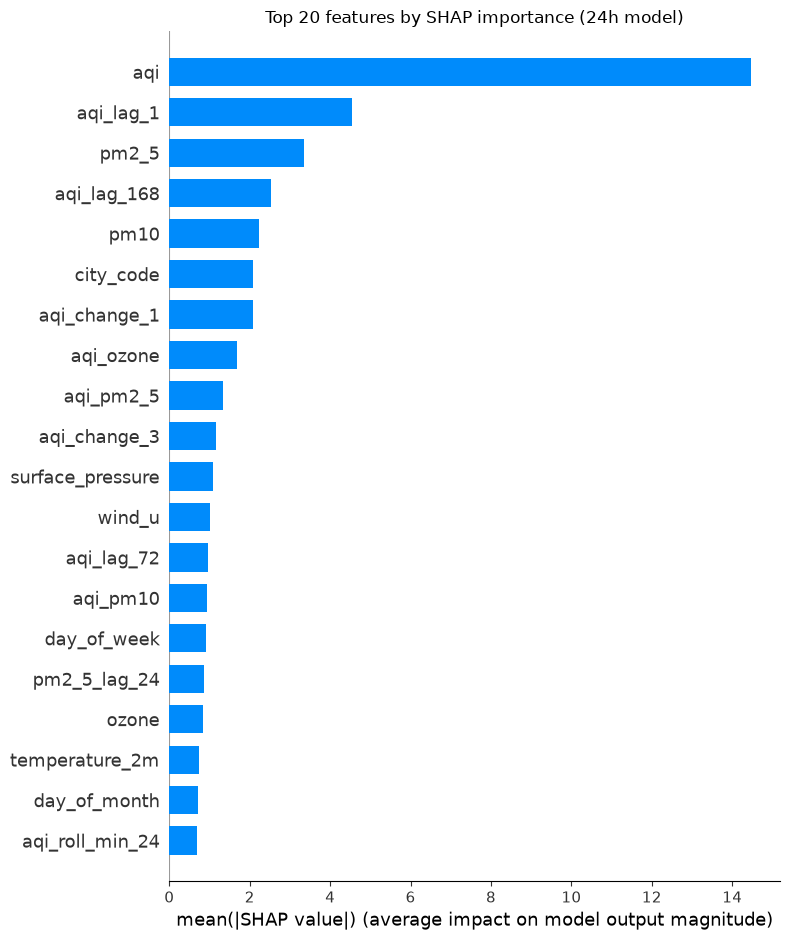

In [34]:
# bar plot of mean absolute SHAP value per feature, top 20
shap.summary_plot(shap_values, sample, plot_type="bar", max_display=20, show=False)
import matplotlib.pyplot as plt
plt.title("Top 20 features by SHAP importance (24h model)")
plt.tight_layout()
plt.savefig("../reports/figures/shap_importance_24h.png", dpi=120, bbox_inches="tight")
plt.show()

### Direction: how each feature pushes the prediction

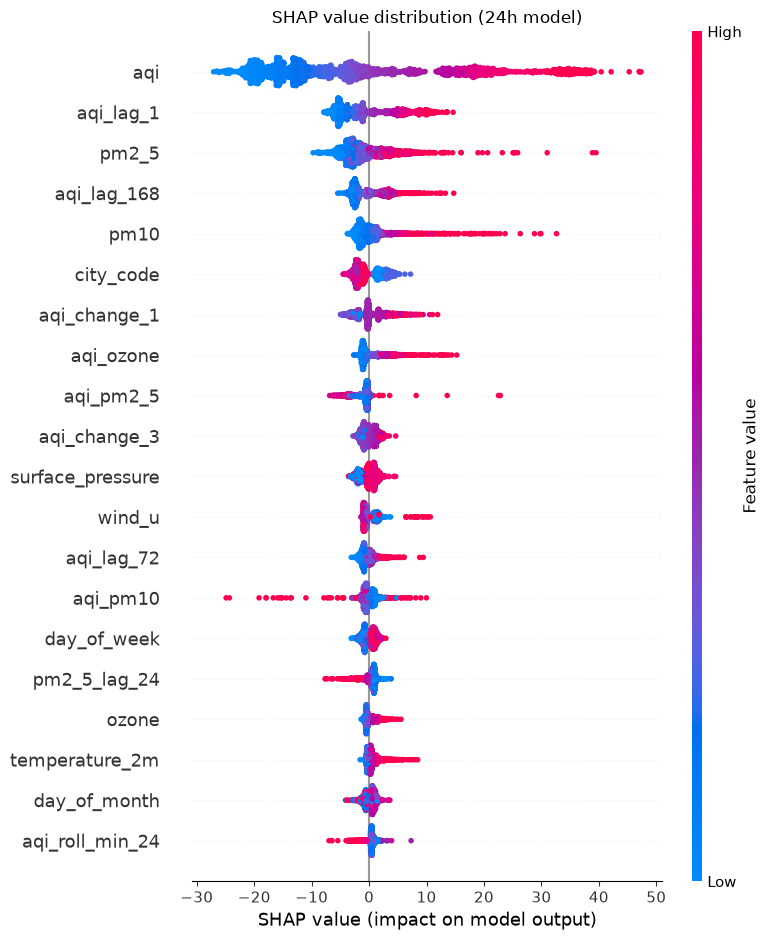

In [35]:
# beeswarm plot: shows direction, high/low feature values pushing AQI up or down
shap.summary_plot(shap_values, sample, max_display=20, show=False)
plt.title("SHAP value distribution (24h model)")
plt.tight_layout()
plt.savefig("../reports/figures/shap_beeswarm_24h.png", dpi=120, bbox_inches="tight")
plt.show()

In [36]:
# the ranked importance as a table, for the report and to save for the dashboard
importance = pd.DataFrame({
    "feature": sample.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

importance.head(20)

,feature,mean_abs_shap
0,aqi,14.464125
1,aqi_lag_1,4.547010
2,pm2_5,3.338002
3,aqi_lag_168,2.522696
4,pm10,2.219280
5,city_code,2.081138
6,aqi_change_1,2.072062
7,aqi_ozone,1.691636
8,aqi_pm2_5,1.322533
9,aqi_change_3,1.158621


In [37]:
# save shap importance into the bundle for the dashboard
import joblib
bundle_path = "../models/aqi_forecaster/bundle.joblib"
bundle = joblib.load(bundle_path)
bundle["shap_importance_24h"] = importance.to_dict(orient="records")
joblib.dump(bundle, bundle_path)
print("saved shap importance into bundle")

saved shap importance into bundle
